# Лабораторна робота №3. Візуалізація даних

**Студент:** Процан Артем Вікторович (ФБ-46)
**Датасет:** Automobile Data Set (UCI Machine Learning Repository)
**Мета:** Очищення даних та побудова 2D, 3D та багатовимірних графіків.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=headers, na_values="?")

print(f"Розмір до очищення: {df.shape}")
print(f"Кількість пропусків:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df = df.dropna(subset=['price', 'horsepower'])

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

numeric_cols = ['price', 'horsepower', 'peak-rpm', 'bore', 'stroke', 'normalized-losses']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nРозмір після очищення: {df.shape}")
display(df.head())

Розмір до очищення: (205, 26)
Кількість пропусків:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Розмір після очищення: (199, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 1. Графік залежності одного integer/real атрибута від іншого
**Аналіз:** Як об'єм двигуна (`engine-size`) впливає на ціну автомобіля (`price`).

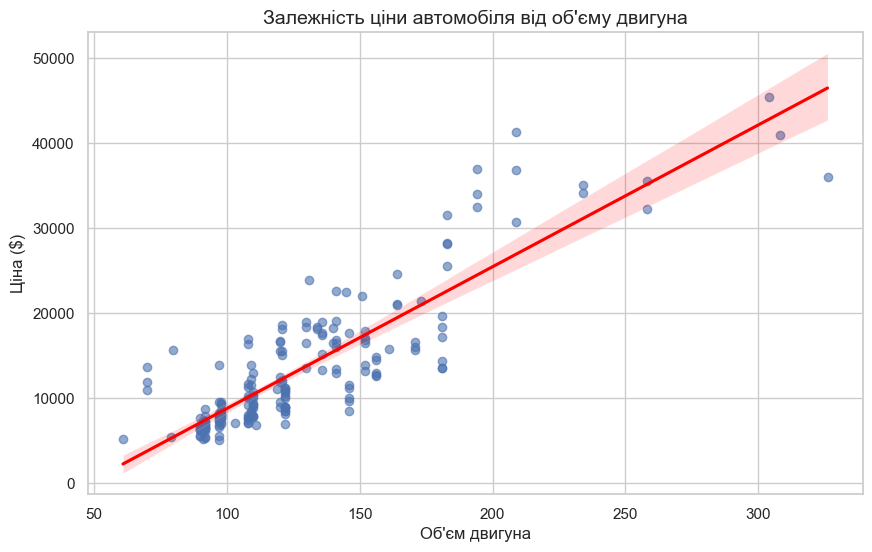

In [3]:
plt.figure(figsize=(10, 6))
sns.regplot(x='engine-size', y='price', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Залежність ціни автомобіля від об\'єму двигуна', fontsize=14)
plt.xlabel('Об\'єм двигуна', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)
plt.show()

### 2. Гістограма по одному з атрибутів у 5 заданих діапазонах
**Аналіз:** Розподіл автомобілів за потужністю (`horsepower`). Діапазони: до 70, 70-100, 100-150, 150-200, 200+.

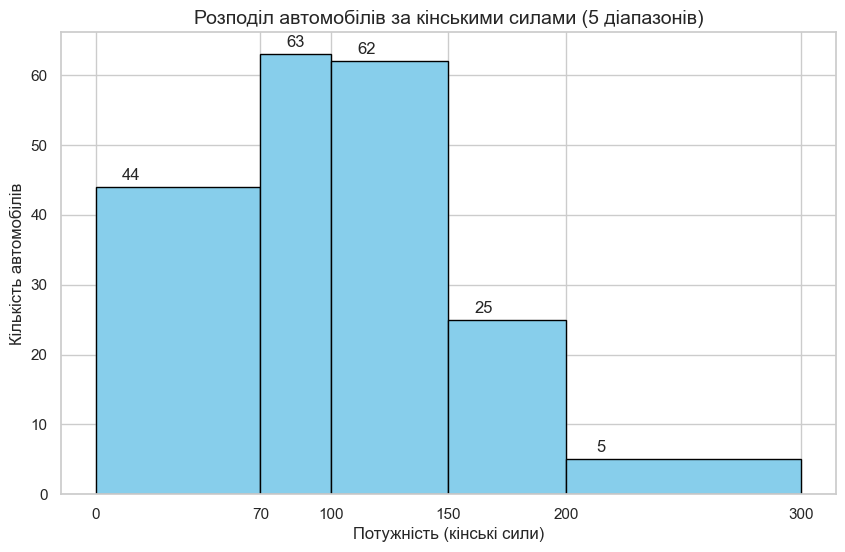

In [4]:
plt.figure(figsize=(10, 6))

custom_bins = [0, 70, 100, 150, 200, 300]
bin_labels = ['До 70', '70-100', '100-150', '150-200', '200+']

counts, edges, patches = plt.hist(df['horsepower'], bins=custom_bins, color='skyblue', edgecolor='black')

plt.title('Розподіл автомобілів за кінськими силами (5 діапазонів)', fontsize=14)
plt.xlabel('Потужність (кінські сили)', fontsize=12)
plt.ylabel('Кількість автомобілів', fontsize=12)
plt.xticks(custom_bins)

for count, edge in zip(counts, edges):
    if count > 0:
        plt.text(edge + 15, count + 1, str(int(count)), ha='center')

plt.show()

### 3. Багатовимірна візуалізація
**Аналіз:** Візуалізація одразу 4-х вимірів: `highway-mpg` (X), `price` (Y), `fuel-type` (Колір), `horsepower` (Розмір точки).

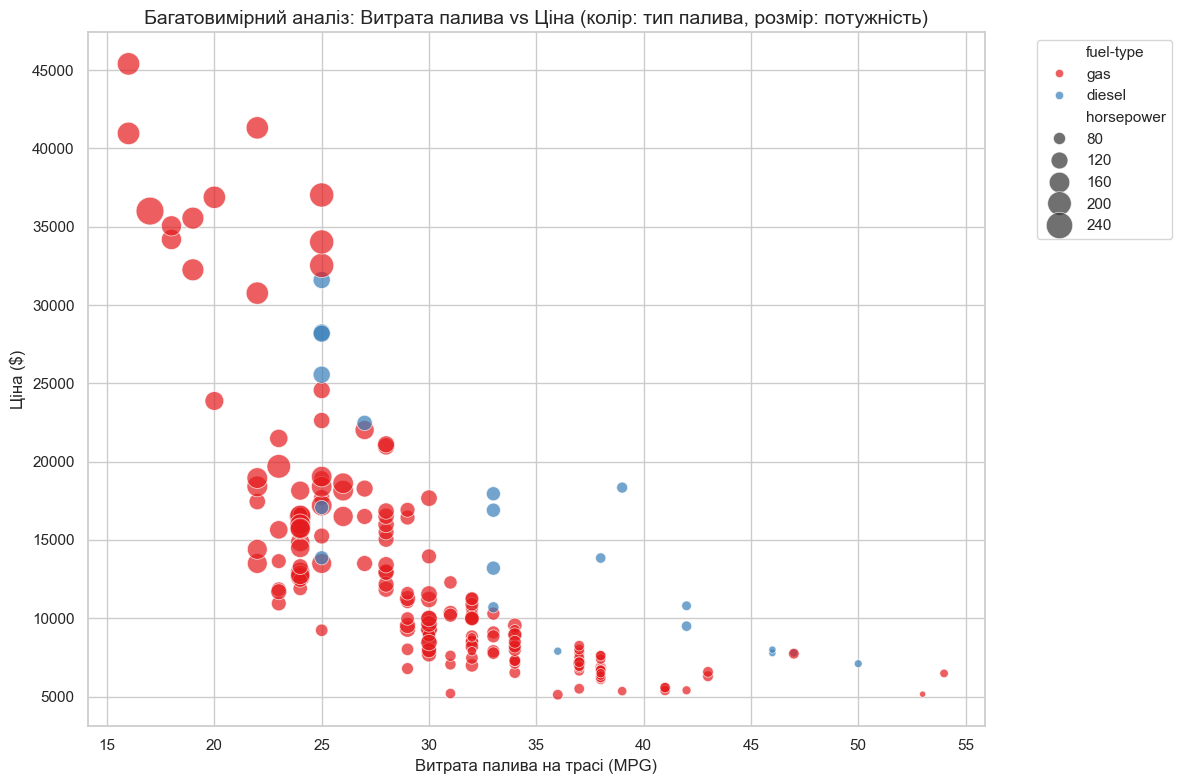

In [5]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='highway-mpg', 
    y='price', 
    hue='fuel-type',
    size='horsepower',
    sizes=(20, 400),
    alpha=0.7,
    palette='Set1'
)
plt.title('Багатовимірний аналіз: Витрата палива vs Ціна (колір: тип палива, розмір: потужність)', fontsize=14)
plt.xlabel('Витрата палива на трасі (MPG)', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Інші корисні графіки для розуміння датасету
Побудуємо Boxplot (ящик з вусами), стовпчикову діаграму середньої ціни та теплову карту кореляцій (Heatmap).

C:\Users\Artem\AppData\Local\Temp\ipykernel_17928\762975511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body-style', y='price', data=df, palette='pastel')


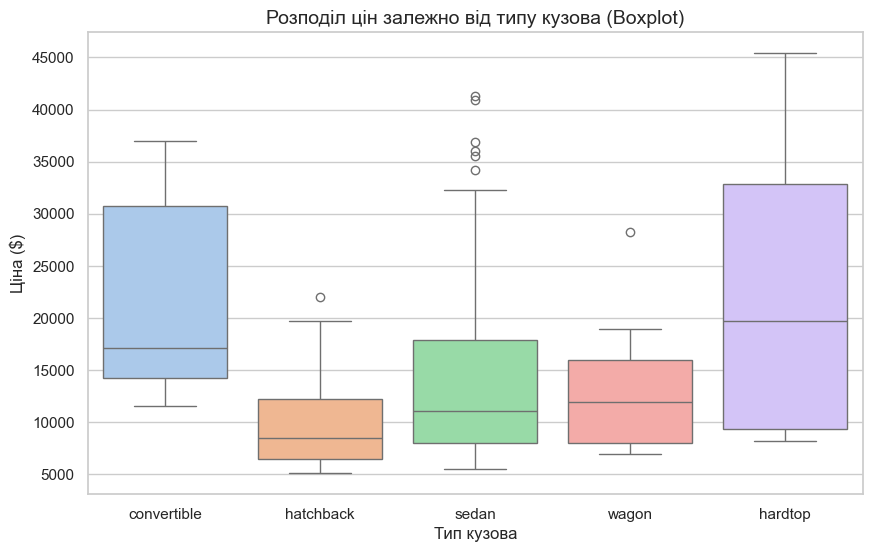

C:\Users\Artem\AppData\Local\Temp\ipykernel_17928\762975511.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_make.index, y=avg_price_make.values, palette='viridis')


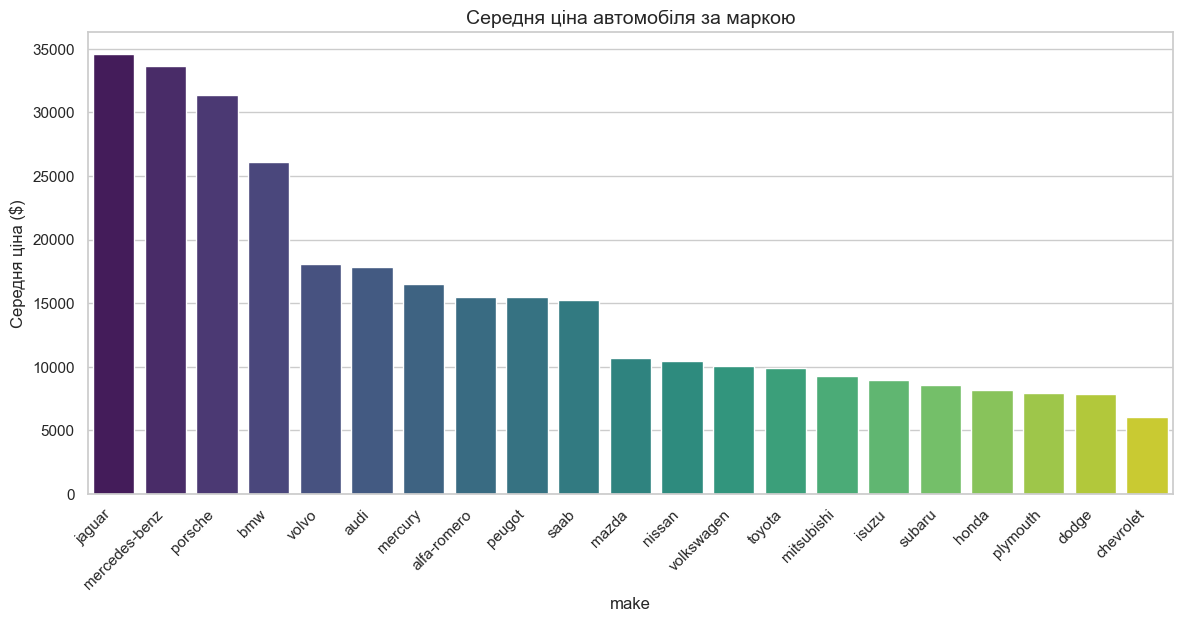

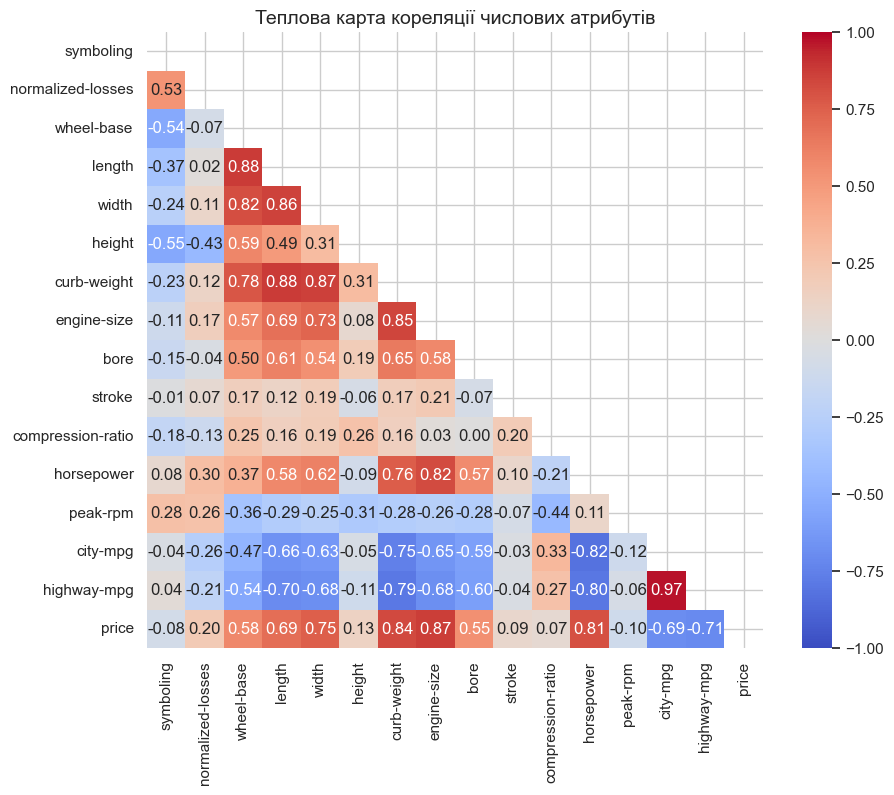

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='body-style', y='price', data=df, palette='pastel')
plt.title('Розподіл цін залежно від типу кузова (Boxplot)', fontsize=14)
plt.xlabel('Тип кузова', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)
plt.show()

plt.figure(figsize=(14, 6))
avg_price_make = df.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_make.index, y=avg_price_make.values, palette='viridis')
plt.title('Середня ціна автомобіля за маркою', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Середня ціна ($)')
plt.show()

plt.figure(figsize=(10, 8))
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Теплова карта кореляції числових атрибутів', fontsize=14)
plt.show()